# Libraries

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
# Visualization
import matplotlib.pyplot as plt
# Data preprocessing
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
# Neural Network regression model
from sklearn.neural_network import MLPRegressor
# Model evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# Data

## Load the Dataset

In [3]:
DATA_PATH = Path("retail_store_inventory.csv") # file path
raw_df = pd.read_csv(DATA_PATH) # loading the original dataset

In [4]:
df = raw_df.copy() # Create a working copy so the original raw dataset remains unchanged

In [5]:
df["Date"] = pd.to_datetime(df["Date"]) # Convert the Date column into datetime format

In [6]:
print("Dataset shape:", df.shape)
print("\nFirst five rows:")
display(df.head())

Dataset shape: (73100, 15)

First five rows:


,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer
3,2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer


In [7]:
print("\nColumn names:")
print(df.columns.tolist())


Column names:
['Date', 'Store ID', 'Product ID', 'Category', 'Region', 'Inventory Level', 'Units Sold', 'Units Ordered', 'Demand Forecast', 'Price', 'Discount', 'Weather Condition', 'Holiday/Promotion', 'Competitor Pricing', 'Seasonality']


## Separate the Five Isolated Rows

In [8]:
latest_date = df["Date"].max() # Identify the most recent date in the dataset

In [9]:
isolated_rows = (
    df[df["Date"] == latest_date]
    .sample(n=5, random_state=42)
    .copy()
)

#Select five rows from the most recent date. These rows will be completely isolated from model development

In [10]:
model_df = df.drop(index=isolated_rows.index).copy() # Remove the isolated rows from the dataset used for model building

In [11]:
isolated_rows.insert(0, "Original_Row_Number", isolated_rows.index + 2) # Add the original row number for easier tracking in the final report

In [12]:
# Display the results
print("Latest date:", latest_date.date())
print("Original dataset rows:", len(df))
print("Rows reserved for isolated testing:", len(isolated_rows))
print("Rows remaining for model development:", len(model_df))

print("\nFive isolated rows:")
display(isolated_rows)

Latest date: 2024-01-01
Original dataset rows: 73100
Rows reserved for isolated testing: 5
Rows remaining for model development: 73095

Five isolated rows:


,Original_Row_Number,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
73083,73085,2024-01-01,S005,P0004,Toys,North,158,85,193,85.16,77.29,10,Cloudy,1,73.66,Autumn
73053,73055,2024-01-01,S003,P0014,Electronics,West,230,74,190,85.49,73.40,20,Cloudy,1,72.65,Spring
73070,73072,2024-01-01,S004,P0011,Groceries,East,155,107,47,123.65,88.17,20,Snowy,1,90.26,Autumn
73045,73047,2024-01-01,S003,P0006,Furniture,North,451,366,200,372.01,24.39,0,Sunny,0,28.31,Winter
73044,73046,2024-01-01,S003,P0005,Electronics,West,411,291,200,298.09,82.16,20,Sunny,1,79.32,Summer


## Save the Five Rows Separately

In [14]:
# Save the isolated rows separately for the final prediction comparison
isolated_rows.to_csv("isolated_5_rows.csv", index=False)

print("The five isolated rows were saved successfully.")

The five isolated rows were saved successfully.


# Inspect the Remaining Modeling Dataset

## Data Inspection

After removing five isolated rows for final testing, the remaining dataset was inspected 
for missing values, duplicate rows, data types, unusual values, and categorical variables. 
This step helps identify any data-cleaning actions required before preprocessing and 
Neural Network model development.

In [15]:
# Inspect the remaining modeling dataset
print("Modeling dataset shape:", model_df.shape)

print("\nColumn names:")
print(model_df.columns.tolist())

print("\nData types:")
print(model_df.dtypes)

print("\nMissing values:")
print(model_df.isnull().sum())

print("\nDuplicate rows:")
print(model_df.duplicated().sum())

print("\nSummary statistics for numerical columns:")
display(model_df.describe())

Modeling dataset shape: (73095, 15)

Column names:
['Date', 'Store ID', 'Product ID', 'Category', 'Region', 'Inventory Level', 'Units Sold', 'Units Ordered', 'Demand Forecast', 'Price', 'Discount', 'Weather Condition', 'Holiday/Promotion', 'Competitor Pricing', 'Seasonality']

Data types:
Date                  datetime64[ns]
Store ID                      object
Product ID                    object
Category                      object
Region                        object
Inventory Level                int64
Units Sold                     int64
Units Ordered                  int64
Demand Forecast              float64
Price                        float64
Discount                       int64
Weather Condition             object
Holiday/Promotion              int64
Competitor Pricing           float64
Seasonality                   object
dtype: object

Missing values:
Date                  0
Store ID              0
Product ID            0
Category              0
Region                0
Inve

,Date,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Holiday/Promotion,Competitor Pricing
count,73095,73095.000000,73095.000000,73095.000000,73095.000000,73095.000000,73095.000000,73095.000000,73095.000000
mean,2022-12-31 23:24:02.807305216,274.469430,136.461577,110.000643,141.491205,55.134154,10.009235,0.497284,55.145141
min,2022-01-01 00:00:00,50.000000,0.000000,20.000000,-9.990000,10.000000,0.000000,0.000000,5.030000
25%,2022-07-02 00:00:00,162.000000,49.000000,65.000000,53.670000,32.650000,5.000000,0.000000,32.680000
50%,2023-01-01 00:00:00,273.000000,107.000000,110.000000,113.010000,55.050000,10.000000,0.000000,55.010000
75%,2023-07-03 00:00:00,387.000000,203.000000,155.000000,208.045000,77.860000,15.000000,1.000000,77.815000
max,2024-01-01 00:00:00,500.000000,499.000000,200.000000,518.550000,100.000000,20.000000,1.000000,104.940000
std,NaN,129.949768,108.917857,52.274859,109.252536,26.021891,7.083603,0.499996,26.191471


In [16]:
# Identify numerical columns
numerical_columns = model_df.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Numerical columns:")
print(numerical_columns)

print("\nNegative-value check:")
for column in numerical_columns:
    negative_count = (model_df[column] < 0).sum()
    print(f"{column}: {negative_count} negative values")

Numerical columns:
['Inventory Level', 'Units Sold', 'Units Ordered', 'Demand Forecast', 'Price', 'Discount', 'Holiday/Promotion', 'Competitor Pricing']

Negative-value check:
Inventory Level: 0 negative values
Units Sold: 0 negative values
Units Ordered: 0 negative values
Demand Forecast: 673 negative values
Price: 0 negative values
Discount: 0 negative values
Holiday/Promotion: 0 negative values
Competitor Pricing: 0 negative values


In [17]:
# Identify categorical columns
categorical_columns = model_df.select_dtypes(include=["object"]).columns.tolist()

print("Categorical columns:")
print(categorical_columns)

for column in categorical_columns:
    print(f"\n{column}:")
    print(model_df[column].unique())

Categorical columns:
['Store ID', 'Product ID', 'Category', 'Region', 'Weather Condition', 'Seasonality']

Store ID:
['S001' 'S002' 'S003' 'S004' 'S005']

Product ID:
['P0001' 'P0002' 'P0003' 'P0004' 'P0005' 'P0006' 'P0007' 'P0008' 'P0009'
 'P0010' 'P0011' 'P0012' 'P0013' 'P0014' 'P0015' 'P0016' 'P0017' 'P0018'
 'P0019' 'P0020']

Category:
['Groceries' 'Toys' 'Electronics' 'Furniture' 'Clothing']

Region:
['North' 'South' 'West' 'East']

Weather Condition:
['Rainy' 'Sunny' 'Cloudy' 'Snowy']

Seasonality:
['Autumn' 'Summer' 'Winter' 'Spring']


## Clean Negative Demand Forecast Values

The data inspection identified negative values in the `Demand Forecast` column. 
A negative demand forecast is not meaningful for inventory planning. Therefore, 
negative forecast values were replaced with zero in the modeling dataset. 

The target variable, `Units Sold`, was not modified.

In [18]:
# Count negative values before cleaning
negative_before = (model_df["Demand Forecast"] < 0).sum()

print("Negative Demand Forecast values before cleaning:", negative_before)

# Replace negative demand forecasts with zero
model_df["Demand Forecast"] = model_df["Demand Forecast"].clip(lower=0)

# Confirm that the issue was fixed
negative_after = (model_df["Demand Forecast"] < 0).sum()

print("Negative Demand Forecast values after cleaning:", negative_after)

Negative Demand Forecast values before cleaning: 673
Negative Demand Forecast values after cleaning: 0


In [19]:
# Save the cleaned modeling dataset
model_df.to_csv("cleaned_modeling_dataset.csv", index=False)

print("The cleaned modeling dataset was saved successfully.")

The cleaned modeling dataset was saved successfully.


# Feature-Engineering Function

The target variable is `Units Sold`, which represents the number of units sold for a 
product during a day. The raw `Date` column was converted into year, month, and day-of-week 
features. The original date was then removed.

The `Units Ordered` column was excluded from the first model because it represents a 
replenishment decision. The objective is to predict demand before making stock-allocation 
and ordering decisions.

In [20]:
# Target variable
TARGET = "Units Sold"

def prepare_features(data):
    """
    Apply fixed feature-engineering rules.
    This function does not fit a scaler or encoder.
    """
    
    prepared = data.copy()
    
    # Ensure Date uses datetime format
    prepared["Date"] = pd.to_datetime(prepared["Date"])
    
    # Apply the fixed business rule for unrealistic negative forecasts
    prepared["Demand Forecast"] = prepared["Demand Forecast"].clip(lower=0)
    
    # Extract useful date information
    prepared["Date_Year"] = prepared["Date"].dt.year
    prepared["Date_Month"] = prepared["Date"].dt.month.astype(str)
    prepared["Date_DayOfWeek"] = prepared["Date"].dt.dayofweek.astype(str)
    
    # Remove the raw date and the replenishment-decision column
    prepared = prepared.drop(columns=["Date", "Units Ordered"])
    
    return prepared

## Apply the Function Only to the Modeling Dataset

In [22]:
# Apply feature engineering only to the modeling dataset
prepared_model_df = prepare_features(model_df)

print("Prepared modeling dataset shape:", prepared_model_df.shape)

print("\nPrepared columns:")
print(prepared_model_df.columns.tolist())

display(prepared_model_df.head())

Prepared modeling dataset shape: (73095, 16)

Prepared columns:
['Store ID', 'Product ID', 'Category', 'Region', 'Inventory Level', 'Units Sold', 'Demand Forecast', 'Price', 'Discount', 'Weather Condition', 'Holiday/Promotion', 'Competitor Pricing', 'Seasonality', 'Date_Year', 'Date_Month', 'Date_DayOfWeek']


,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality,Date_Year,Date_Month,Date_DayOfWeek
0,S001,P0001,Groceries,North,231,127,135.47,33.50,20,Rainy,0,29.69,Autumn,2022,1,5
1,S001,P0002,Toys,South,204,150,144.04,63.01,20,Sunny,0,66.16,Autumn,2022,1,5
2,S001,P0003,Toys,West,102,65,74.02,27.99,10,Sunny,1,31.32,Summer,2022,1,5
3,S001,P0004,Toys,North,469,61,62.18,32.72,10,Cloudy,1,34.74,Autumn,2022,1,5
4,S001,P0005,Electronics,East,166,14,9.26,73.64,0,Sunny,0,68.95,Summer,2022,1,5


In [23]:
# Separate predictor variables from the target variable
X = prepared_model_df.drop(columns=[TARGET])
y = prepared_model_df[TARGET].copy()

print("Input dataset shape:", X.shape)
print("Target dataset shape:", y.shape)

print("\nTarget variable summary:")
print(y.describe())

Input dataset shape: (73095, 15)
Target dataset shape: (73095,)

Target variable summary:
count    73095.000000
mean       136.461577
std        108.917857
min          0.000000
25%         49.000000
50%        107.000000
75%        203.000000
max        499.000000
Name: Units Sold, dtype: float64


In [24]:
# Identify categorical and numerical input columns
categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("Categorical input features:")
for column in categorical_features:
    print("-", column)

print("\nNumerical input features:")
for column in numerical_features:
    print("-", column)

print("\nNumber of categorical features:", len(categorical_features))
print("Number of numerical features:", len(numerical_features))

Categorical input features:
- Store ID
- Product ID
- Category
- Region
- Weather Condition
- Seasonality
- Date_Month
- Date_DayOfWeek

Numerical input features:
- Inventory Level
- Demand Forecast
- Price
- Discount
- Holiday/Promotion
- Competitor Pricing

Number of categorical features: 8
Number of numerical features: 6


# Divide the Data Into Training and Testing Sets

The remaining modeling dataset was divided into training and testing sets using an 
80%–20% chronological split. The earlier 80% of the records were assigned to the training 
set, while the most recent 20% were assigned to the testing set. 

A chronological split was selected because the objective is to predict future-style 
product demand using historical data. The five isolated rows reserved for final testing 
were not included in either dataset.

In [25]:
# Sort the modeling dataset chronologically before splitting
sorted_model_df = model_df.sort_values(by="Date").copy()

# Apply the fixed feature-engineering rules
prepared_model_df = prepare_features(sorted_model_df)

# Separate predictors and target variable
X = prepared_model_df.drop(columns=[TARGET])
y = prepared_model_df[TARGET].copy()

# Calculate the 80% split position
split_index = int(len(X) * 0.80)

# Earlier 80% for training
train_X = X.iloc[:split_index].copy()
train_y = y.iloc[:split_index].copy()

# Most recent 20% for testing
test_X = X.iloc[split_index:].copy()
test_y = y.iloc[split_index:].copy()

# Display dataset sizes
print("Total modeling rows:", len(X))
print("Training rows:", len(train_X))
print("Testing rows:", len(test_X))
print("Isolated rows reserved separately:", len(isolated_rows))

print("\nTraining percentage:", round(len(train_X) / len(X) * 100, 2), "%")
print("Testing percentage:", round(len(test_X) / len(X) * 100, 2), "%")

Total modeling rows: 73095
Training rows: 58476
Testing rows: 14619
Isolated rows reserved separately: 5

Training percentage: 80.0 %
Testing percentage: 20.0 %


In [26]:
# Confirm the chronological split using the original sorted dataset
train_dates = sorted_model_df["Date"].iloc[:split_index]
test_dates = sorted_model_df["Date"].iloc[split_index:]

print("Training period:")
print(train_dates.min().date(), "to", train_dates.max().date())

print("\nTesting period:")
print(test_dates.min().date(), "to", test_dates.max().date())

Training period:
2022-01-01 to 2023-08-08

Testing period:
2023-08-08 to 2024-01-01


# Preprocessing the Input Features

The numerical predictors were scaled to the 0–1 range using `MinMaxScaler`. 
The categorical predictors were converted into dummy variables using `OneHotEncoder`.

The preprocessing transformer was fitted only on the training dataset to prevent 
information from the testing dataset from influencing model development. The fitted 
transformer was then applied to the testing dataset.

The five isolated rows reserved for the final evaluation were not used during this step.

In [27]:
# Create an encoder that works with different scikit-learn versions
try:
    encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    )
except TypeError:
    encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse=False
    )

# Create the preprocessing transformer
preprocessor = ColumnTransformer(
    transformers=[
        ("numerical", MinMaxScaler(), numerical_features),
        ("categorical", encoder, categorical_features)
    ]
)

# Fit preprocessing tools only on the training data
train_X_processed = preprocessor.fit_transform(train_X)

# Apply the fitted preprocessing tools to the testing data
test_X_processed = preprocessor.transform(test_X)

print("Original training shape:", train_X.shape)
print("Processed training shape:", train_X_processed.shape)

print("\nOriginal testing shape:", test_X.shape)
print("Processed testing shape:", test_X_processed.shape)

Original training shape: (58476, 15)
Processed training shape: (58476, 67)

Original testing shape: (14619, 15)
Processed testing shape: (14619, 67)


In [28]:
# Retrieve the processed feature names
processed_feature_names = preprocessor.get_feature_names_out()

print("Number of processed input features:", len(processed_feature_names))

print("\nProcessed feature names:")
for feature in processed_feature_names:
    print("-", feature)

Number of processed input features: 67

Processed feature names:
- numerical__Inventory Level
- numerical__Demand Forecast
- numerical__Price
- numerical__Discount
- numerical__Holiday/Promotion
- numerical__Competitor Pricing
- categorical__Store ID_S001
- categorical__Store ID_S002
- categorical__Store ID_S003
- categorical__Store ID_S004
- categorical__Store ID_S005
- categorical__Product ID_P0001
- categorical__Product ID_P0002
- categorical__Product ID_P0003
- categorical__Product ID_P0004
- categorical__Product ID_P0005
- categorical__Product ID_P0006
- categorical__Product ID_P0007
- categorical__Product ID_P0008
- categorical__Product ID_P0009
- categorical__Product ID_P0010
- categorical__Product ID_P0011
- categorical__Product ID_P0012
- categorical__Product ID_P0013
- categorical__Product ID_P0014
- categorical__Product ID_P0015
- categorical__Product ID_P0016
- categorical__Product ID_P0017
- categorical__Product ID_P0018
- categorical__Product ID_P0019
- categorical__Produ

## Convert the Processed Arrays Into DataFrames

In [29]:
# Convert processed arrays into DataFrames for easier inspection
train_X_processed_df = pd.DataFrame(
    train_X_processed,
    columns=processed_feature_names,
    index=train_X.index
)

test_X_processed_df = pd.DataFrame(
    test_X_processed,
    columns=processed_feature_names,
    index=test_X.index
)

print("Processed training data:")
display(train_X_processed_df.head())

print("\nProcessed testing data:")
display(test_X_processed_df.head())

Processed training data:


,numerical__Inventory Level,numerical__Demand Forecast,numerical__Price,numerical__Discount,numerical__Holiday/Promotion,numerical__Competitor Pricing,categorical__Store ID_S001,categorical__Store ID_S002,categorical__Store ID_S003,categorical__Store ID_S004,...,categorical__Date_Month_7,categorical__Date_Month_8,categorical__Date_Month_9,categorical__Date_DayOfWeek_0,categorical__Date_DayOfWeek_1,categorical__Date_DayOfWeek_2,categorical__Date_DayOfWeek_3,categorical__Date_DayOfWeek_4,categorical__Date_DayOfWeek_5,categorical__Date_DayOfWeek_6
0,0.402222,0.261248,0.261111,1.00,0.0,0.246822,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
72,0.313333,0.105043,0.575667,0.00,0.0,0.589430,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
71,0.664444,0.001832,0.047222,0.25,1.0,0.135422,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
70,0.344444,0.089962,0.498222,0.00,1.0,0.527775,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
69,0.882222,0.221830,0.260889,0.75,0.0,0.321489,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0



Processed testing data:


,numerical__Inventory Level,numerical__Demand Forecast,numerical__Price,numerical__Discount,numerical__Holiday/Promotion,numerical__Competitor Pricing,categorical__Store ID_S001,categorical__Store ID_S002,categorical__Store ID_S003,categorical__Store ID_S004,...,categorical__Date_Month_7,categorical__Date_Month_8,categorical__Date_Month_9,categorical__Date_DayOfWeek_0,categorical__Date_DayOfWeek_1,categorical__Date_DayOfWeek_2,categorical__Date_DayOfWeek_3,categorical__Date_DayOfWeek_4,categorical__Date_DayOfWeek_5,categorical__Date_DayOfWeek_6
58425,0.993333,0.593308,0.037222,0.00,1.0,0.096987,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
58447,0.422222,0.136573,0.607889,1.00,1.0,0.601742,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
58446,0.544444,0.209604,0.397889,0.75,1.0,0.433390,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
58445,0.780000,0.459609,0.304889,0.50,0.0,0.371234,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
58444,0.266667,0.203529,0.657556,0.00,1.0,0.607547,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [30]:
# Confirm the numerical variables were scaled correctly
print("Minimum processed value:", train_X_processed_df.min().min())
print("Maximum processed value:", train_X_processed_df.max().max())

Minimum processed value: 0.0
Maximum processed value: 1.0


## Target Variable Scaling

The target variable, `Units Sold`, is numerical. It was scaled to the 0–1 range 
using `MinMaxScaler` before training the Neural Network. The scaler was fitted only 
on the training target values to prevent information from the testing dataset from 
influencing model development.

After prediction, the outputs will be converted back into the original unit scale 
so that the results can be interpreted as the predicted number of units sold.

In [32]:
# Create a separate scaler for the numerical target variable
target_scaler = MinMaxScaler()

# Fit the scaler only on the training target values
train_y_scaled = target_scaler.fit_transform(
    train_y.to_numpy().reshape(-1, 1)
).ravel()

print("Original training target range:")
print("Minimum:", train_y.min())
print("Maximum:", train_y.max())

print("\nScaled training target range:")
print("Minimum:", train_y_scaled.min())
print("Maximum:", train_y_scaled.max())

Original training target range:
Minimum: 0
Maximum: 499

Scaled training target range:
Minimum: 0.0
Maximum: 0.9999999999999999


# Neural Network Architecture

A Multi-Layer Perceptron Regressor (`MLPRegressor`) was selected because the 
target variable, `Units Sold`, is numerical.

After preprocessing, the model contains 67 input features. One hidden layer was 
used because it is an appropriate starting structure for a tabular dataset and 
follows the architecture guidelines discussed in the lecture.

The hidden layer contains 46 nodes. This value was calculated using the guideline:

(2/3 × number of input nodes) + number of output nodes

(2/3 × 67) + 1 ≈ 46

The ReLU activation function was selected for the hidden layer because the model 
is solving a numerical prediction problem. The output layer contains one node, 
representing the predicted number of units sold.

In [33]:
# Build the Neural Network regression model
nn_model = MLPRegressor(
    hidden_layer_sizes=(46,),   # One hidden layer containing 46 nodes
    activation="relu",          # Suitable activation function for prediction
    solver="adam",              # Efficient optimizer for a large dataset
    max_iter=500,               # Maximum number of training iterations
    early_stopping=True,        # Stops training when improvement becomes minimal
    validation_fraction=0.10,   # Uses 10% of training data for internal validation
    n_iter_no_change=20,        # Stops after 20 iterations without improvement
    random_state=42
)

print(nn_model)

MLPRegressor(early_stopping=True, hidden_layer_sizes=(46,), max_iter=500,
             n_iter_no_change=20, random_state=42)


# Model Training

The Neural Network was trained using the preprocessed training inputs and the 
scaled training target values. Early stopping was enabled to reduce unnecessary 
iterations and limit overfitting. The model stops training when its internal 
validation performance does not improve sufficiently for 20 consecutive iterations.

In [34]:
# Train the Neural Network
nn_model.fit(train_X_processed, train_y_scaled)

print("Neural Network training completed successfully.")
print("Number of completed iterations:", nn_model.n_iter_)
print("Final training loss:", nn_model.loss_)

Neural Network training completed successfully.
Number of completed iterations: 35
Final training loss: 0.0001821228776116647


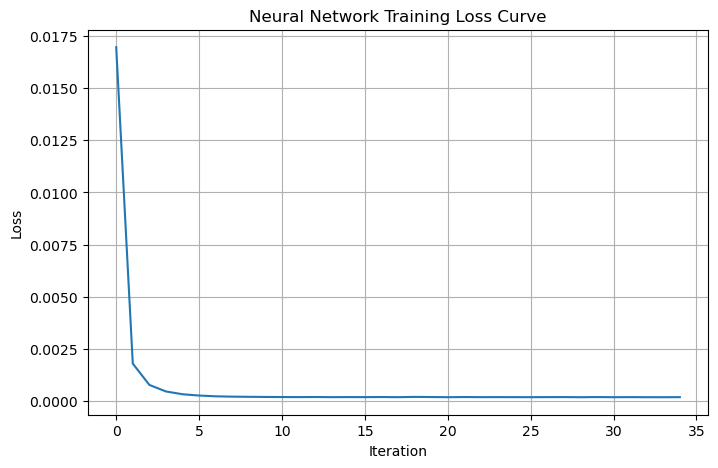

In [35]:
# Plot the training-loss curve
plt.figure(figsize=(8, 5))
plt.plot(nn_model.loss_curve_)
plt.title("Neural Network Training Loss Curve")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

# Model Evaluation

The trained Neural Network was evaluated using the 20% testing dataset. 
These records were not used during model training.

The predictions were converted back from the scaled format into the original 
`Units Sold` scale. The model was evaluated using Mean Absolute Error (MAE), 
Root Mean Squared Error (RMSE), and the R² score.

In [36]:
# Predict the scaled values for the regular testing dataset
test_predictions_scaled = nn_model.predict(test_X_processed)

# Convert the scaled predictions back into the original Units Sold scale
test_predictions = target_scaler.inverse_transform(
    test_predictions_scaled.reshape(-1, 1)
).ravel()

# Calculate regression evaluation metrics
test_mae = mean_absolute_error(test_y, test_predictions)
test_rmse = np.sqrt(mean_squared_error(test_y, test_predictions))
test_r2 = r2_score(test_y, test_predictions)

print("Neural Network Testing Performance")
print("----------------------------------")
print("MAE:", round(test_mae, 2))
print("RMSE:", round(test_rmse, 2))
print("R² Score:", round(test_r2, 4))

Neural Network Testing Performance
----------------------------------
MAE: 7.73
RMSE: 9.05
R² Score: 0.993


In [37]:
# Create a sample comparison table
test_results = pd.DataFrame({
    "Actual Units Sold": test_y.values,
    "Predicted Units Sold": test_predictions
})

test_results["Absolute Error"] = (
    test_results["Actual Units Sold"] -
    test_results["Predicted Units Sold"]
).abs()

print("Sample testing predictions:")
display(test_results.head(10).round(2))

Sample testing predictions:


,Actual Units Sold,Predicted Units Sold,Absolute Error
0,304,304.04,0.04
1,62,62.40,0.40
2,102,105.02,3.02
3,219,234.86,15.86
4,100,102.25,2.25
5,307,296.55,10.45
6,195,188.30,6.70
7,159,141.15,17.85
8,141,136.54,4.46
9,274,262.78,11.22


# Final Testing Using Five Isolated Rows

Five observations were removed from the raw dataset before preprocessing and model 
training. These records were not included in the training set, the regular testing set, 
or the fitting of the preprocessing tools.

The trained Neural Network was applied to these isolated records. The predicted number 
of units sold was then compared with the original actual values.

In [38]:
# Load the five original isolated rows
isolated_original = pd.read_csv("isolated_5_rows.csv")

# Convert Date into datetime format
isolated_original["Date"] = pd.to_datetime(isolated_original["Date"])

# Store the actual target values separately
# These values are used only after prediction for comparison
isolated_actual_y = isolated_original[TARGET].copy()

# Keep useful identifying columns for the final results table
tracking_columns = [
    column for column in
    ["Original_Row_Number", "Date", "Store ID", "Product ID"]
    if column in isolated_original.columns
]

isolated_identifiers = isolated_original[tracking_columns].copy()

# Remove the tracking number before feature engineering, if it exists
isolated_for_model = isolated_original.drop(
    columns=["Original_Row_Number"],
    errors="ignore"
)

# Apply the same fixed feature-engineering rules used for the modeling dataset
isolated_prepared = prepare_features(isolated_for_model)

# Remove the target before sending the records into the model
isolated_X = isolated_prepared.drop(columns=[TARGET])

print("Isolated input shape before preprocessing:", isolated_X.shape)
display(isolated_X)

Isolated input shape before preprocessing: (5, 15)


,Store ID,Product ID,Category,Region,Inventory Level,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality,Date_Year,Date_Month,Date_DayOfWeek
0,S005,P0004,Toys,North,158,85.16,77.29,10,Cloudy,1,73.66,Autumn,2024,1,0
1,S003,P0014,Electronics,West,230,85.49,73.40,20,Cloudy,1,72.65,Spring,2024,1,0
2,S004,P0011,Groceries,East,155,123.65,88.17,20,Snowy,1,90.26,Autumn,2024,1,0
3,S003,P0006,Furniture,North,451,372.01,24.39,0,Sunny,0,28.31,Winter,2024,1,0
4,S003,P0005,Electronics,West,411,298.09,82.16,20,Sunny,1,79.32,Summer,2024,1,0


In [43]:
# Apply the already-fitted preprocessing transformer
isolated_X_processed = preprocessor.transform(isolated_X)

# Generate scaled predictions
isolated_predictions_scaled = nn_model.predict(isolated_X_processed)

# Convert predictions back into the original Units Sold scale
isolated_predictions = target_scaler.inverse_transform(
    isolated_predictions_scaled.reshape(-1, 1)
).ravel()

print("Predictions generated successfully.")

Predictions generated successfully.


In [40]:
# Create the final isolated-row comparison table
isolated_results = isolated_identifiers.copy()

isolated_results["Actual Units Sold"] = isolated_actual_y.values
isolated_results["Predicted Units Sold"] = isolated_predictions

isolated_results["Absolute Error"] = (
    isolated_results["Actual Units Sold"] -
    isolated_results["Predicted Units Sold"]
).abs()

# Round values for clear presentation
isolated_results["Predicted Units Sold"] = (
    isolated_results["Predicted Units Sold"].round(2)
)

isolated_results["Absolute Error"] = (
    isolated_results["Absolute Error"].round(2)
)

print("Five Isolated Row Predictions:")
display(isolated_results)

Five Isolated Row Predictions:


,Original_Row_Number,Date,Store ID,Product ID,Actual Units Sold,Predicted Units Sold,Absolute Error
0,73085,2024-01-01,S005,P0004,85,78.27,6.73
1,73055,2024-01-01,S003,P0014,74,80.55,6.55
2,73072,2024-01-01,S004,P0011,107,117.17,10.17
3,73047,2024-01-01,S003,P0006,366,364.81,1.19
4,73046,2024-01-01,S003,P0005,291,293.10,2.10


In [41]:
# Save isolated prediction results for the report
isolated_results.to_csv(
    "isolated_5_rows_prediction_results.csv",
    index=False
)

print("The isolated-row prediction results were saved successfully.")

The isolated-row prediction results were saved successfully.


# Findings and Interpretation

A Multi-Layer Perceptron Regressor was developed to predict daily `Units Sold` for retail products. The purpose of the model is to support automatic stock allocation and reduce warehouse supply inefficiencies. Accurate demand predictions can help the data owner allocate sufficient inventory to stores and products while reducing the risk of shortages and excessive stock.

The dataset was divided chronologically. The earlier 80% of the modeling records were used for training, while the most recent 20% were used for regular testing. Before model development, five additional observations were removed and stored separately for a final isolated test. These five observations were not used during preprocessing, training, or regular testing.

The Neural Network used 67 processed input features. These features included scaled numerical variables and dummy variables created from categorical attributes. The model contained one hidden layer with 46 nodes and one output node. The output node produced the predicted number of units sold.

The Neural Network completed training after 35 iterations. Early stopping prevented unnecessary additional training after the model's performance stopped improving significantly. The final training loss was approximately `0.000182`.

The regular testing dataset produced the following results:

| Metric                         |     Result |
| ------------------------------ | ---------: |
| Mean Absolute Error (MAE)      | 7.73 units |
| Root Mean Squared Error (RMSE) | 9.05 units |
| R² Score                       |     0.9930 |

The MAE indicates that the predicted daily sales differed from the actual values by approximately 7.73 units on average. The RMSE of 9.05 units shows that larger errors remained relatively limited. The R² score of 0.9930 indicates that the model explained approximately 99.3% of the variation in `Units Sold`.

The model was also tested using the five isolated observations removed before training. The results were:

| Store | Product | Actual Units Sold | Predicted Units Sold | Absolute Error |
| ----- | ------- | ----------------: | -------------------: | -------------: |
| S005  | P0004   |                85 |                78.27 |           6.73 |
| S003  | P0014   |                74 |                80.55 |           6.55 |
| S004  | P0011   |               107 |               117.17 |          10.17 |
| S003  | P0006   |               366 |               364.81 |           1.19 |
| S003  | P0005   |               291 |               293.10 |           2.10 |

The average absolute error for the five isolated observations was approximately `5.35` units. The closest isolated prediction differed from the actual value by only `1.19` units. The largest isolated error was `10.17` units.

Overall, the Neural Network generated accurate predictions for both the regular testing dataset and the five isolated observations. The results suggest that the model can support inventory-planning decisions by helping the data owner estimate daily product demand and allocate warehouse stock more effectively.

The `Demand Forecast` variable was included as an input because it represents an existing estimate that may be available before the stock-allocation decision. Therefore, the Neural Network can be interpreted as improving the existing forecast by combining it with inventory, pricing, promotional, seasonal, store, and product-related information.
